# Chicago Crime - Baseline Predictive Modeling

**Goal**: Achieve ≥0.75 accuracy for predicting:
- **Crime Category** (5 classes: Violent, Theft, Property, Narcotics, Other)
- **Beat** (top locations for police deployment)
- **HourBin** (time-of-day for crime timing)

**Scope**: Load data, feature preparation, baseline models (LR, RF, GB) with GridSearchCV, experiment log, and feature importance. For advanced experiments (SVM, KNN, data prep, LightGBM v2), see `05_advanced_modeling.ipynb`.

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score, accuracy_score
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/processed/crimes_cleaned.csv')
print("Shape:", df.shape)
df.head(3)

Shape: (2441506, 28)


,ID,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,Beat,...,DayOfWeek,DayOfWeekName,Hour,Quarter,WeekOfYear,IsWeekend,Lat_bin,Lon_bin,HourBin,Crime_Category
0,14135339,2026-03-13 00:00:00,075XX S KINGSTON AVE,0760,BURGLARY,BURGLARY FROM MOTOR VEHICLE,STREET,0,0,421,...,4,Friday,0,1,11,False,2087,-4379,0,Theft
1,14135179,2026-03-13 00:00:00,050XX N MARINE DR,1310,CRIMINAL DAMAGE,TO PROPERTY,RESIDENCE - GARAGE,0,0,2024,...,4,Friday,0,1,11,False,2098,-4383,0,Property
2,14138214,2026-03-13 00:00:00,075XX S STONY ISLAND AVE,0281,CRIMINAL SEXUAL ASSAULT,NON-AGGRAVATED,HOSPITAL BUILDING / GROUNDS,0,0,411,...,4,Friday,0,1,11,False,2087,-4380,0,Violent


## 1. Ensure Modeling Columns Exist

Add Lat_bin, Lon_bin, HourBin, Crime_Category if not present (for compatibility with older cleaned data).

In [49]:
if 'Lat_bin' not in df.columns:
    df['Lat_bin'] = (df['Latitude'] // 0.02).astype(int)
if 'Lon_bin' not in df.columns:
    df['Lon_bin'] = (df['Longitude'] // 0.02).astype(int)
if 'HourBin' not in df.columns:
    def get_hour_bin(h):
        if 0 <= h < 4: return 0
        if 4 <= h < 8: return 1
        if 8 <= h < 12: return 2
        if 12 <= h < 16: return 3
        if 16 <= h < 20: return 4
        return 5
    df['HourBin'] = df['Hour'].apply(get_hour_bin)
if 'Crime_Category' not in df.columns:
    CRIME_MAP = {'Violent': ['BATTERY','ASSAULT','ROBBERY','CRIMINAL SEXUAL ASSAULT','HOMICIDE','KIDNAPPING'],
                 'Theft': ['THEFT','MOTOR VEHICLE THEFT','BURGLARY'], 'Property': ['CRIMINAL DAMAGE','CRIMINAL TRESPASS','ARSON'],
                 'Narcotics': ['NARCOTICS','OTHER NARCOTIC VIOLATION'], 'Other': []}
    def map_cat(pt):
        for c, t in CRIME_MAP.items():
            if pt in t: return c
        return 'Other'
    df['Crime_Category'] = df['Primary Type'].apply(map_cat)

top_loc = df['Location Description'].value_counts().head(20).index.tolist()
df['Location_enc'] = df['Location Description'].apply(lambda x: x if x in top_loc else 'OTHER')
df['Location_enc'] = LabelEncoder().fit_transform(df['Location_enc'].astype(str))

# Sample for faster training
SAMPLE_SIZE = 200000
if len(df) > SAMPLE_SIZE:
    df = df.sample(n=SAMPLE_SIZE, random_state=42)
print("Sample size:", len(df))

Sample size: 200000


## 2. Prepare Features and Targets (Aligned with Predictions)

**Task 1 - Crime Category (5 classes)**: Beat, Lat_bin, Lon_bin, HourBin, DayOfWeek, Month, Location_enc, Domestic

**Task 2 - Beat (top 25 for balance)**: Lat_bin, Lon_bin, Crime_Category, HourBin, DayOfWeek, Month, Location_enc, Community_Area

**Task 3 - HourBin (6 classes)**: Beat, Crime_Category, DayOfWeek, Month, Location_enc, IsWeekend

In [51]:
df['Community_Area'] = df['Community Area'].fillna(-1).astype(int)

# Task 1: Crime Category
feat_crime = ['Beat', 'Lat_bin', 'Lon_bin', 'HourBin', 'DayOfWeek', 'Month', 'Location_enc', 'Domestic']
X1 = df[feat_crime].astype(float)
y1 = df['Crime_Category']

# Task 2: Top 25 Beats
top_beats = df['Beat'].value_counts().head(25).index.tolist()
mask_b = df['Beat'].isin(top_beats)
feat_beat = ['Lat_bin', 'Lon_bin', 'HourBin', 'DayOfWeek', 'Month', 'Location_enc', 'Community_Area']
df['Crime_Cat_enc'] = LabelEncoder().fit_transform(df['Crime_Category'])
feat_beat2 = ['Lat_bin', 'Lon_bin', 'Crime_Cat_enc', 'HourBin', 'DayOfWeek', 'Month', 'Location_enc', 'Community_Area']
X2 = df.loc[mask_b, feat_beat2].astype(float)
y2 = df.loc[mask_b, 'Beat'].astype(str)

# Task 3: HourBin
feat_hour = ['Beat', 'Crime_Cat_enc', 'DayOfWeek', 'Month', 'Location_enc', 'IsWeekend']
X3 = df[feat_hour].astype(float)
X3['IsWeekend'] = X3['IsWeekend'].astype(int)
y3 = df['HourBin']

print("Task 1 (Crime Cat):", X1.shape, y1.value_counts().to_dict())
print("Task 2 (Beat):", X2.shape)
print("Task 3 (HourBin):", X3.shape)

Task 1 (Crime Cat): (200000, 8) {'Theft': 65691, 'Violent': 62847, 'Other': 37517, 'Property': 27019, 'Narcotics': 6926}
Task 2 (Beat): (32984, 8)
Task 3 (HourBin): (200000, 6)


## 3. Experiment Log & Hyperparameter Tuning

Document all experiments: model, params, accuracy, F1. Use GridSearchCV for hyperparameter tuning.

In [52]:
EXPERIMENT_LOG = []

def log_experiment(task, model_name, params, accuracy, f1, notes=""):
    EXPERIMENT_LOG.append({
        'task': task, 'model': model_name, 'params': str(params),
        'accuracy': round(float(accuracy), 4), 'f1_weighted': round(float(f1), 4), 'notes': notes
    })

def run_experiments(X, y, task_name, min_samples=2):
    class_counts = y.value_counts()
    valid = class_counts[class_counts >= min_samples].index
    m = y.isin(valid)
    Xf, yf = X[m].reset_index(drop=True), y[m].reset_index(drop=True)
    if len(Xf) < len(X):
        print(f"  Filtered {(~m).sum()} rare-class samples")

    X_tr, X_te, y_tr, y_te = train_test_split(Xf, yf, test_size=0.2, random_state=42, stratify=yf)
    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    X_te_s = scaler.transform(X_te)

    results = []
    models = {
        'LR': LogisticRegression(max_iter=1000, random_state=42),
        'RF': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
        'GB': GradientBoostingClassifier(n_estimators=100, random_state=42)
    }
    for name, mdl in models.items():
        mdl.fit(X_tr_s, y_tr)
        pred = mdl.predict(X_te_s)
        acc = accuracy_score(y_te, pred)
        f1 = f1_score(y_te, pred, average='weighted')
        results.append((name, {}, acc, f1))
        log_experiment(task_name, name, {}, acc, f1)

    # GridSearch on best base model (GradientBoosting)
    param_grid = {
        'n_estimators': [100, 200],
        'max_depth': [5, 8, 10],
        'learning_rate': [0.05, 0.1]
    }
    gs = GridSearchCV(GradientBoostingClassifier(random_state=42), param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=0)
    gs.fit(X_tr_s, y_tr)
    pred_gs = gs.predict(X_te_s)
    acc_gs = accuracy_score(y_te, pred_gs)
    f1_gs = f1_score(y_te, pred_gs, average='weighted')
    log_experiment(task_name, 'GB_tuned', gs.best_params_, acc_gs, f1_gs, 'GridSearch')

    best_acc = max(r[2] for r in results + [('GS', gs.best_params_, acc_gs, f1_gs)])
    print(f"\n--- {task_name} ---")
    for r in results:
        print(f"  {r[0]}: Acc={r[2]:.4f} F1={r[3]:.4f}")
    print(f"  GB_tuned: Acc={acc_gs:.4f} F1={f1_gs:.4f} (best params: {gs.best_params_})")
    print(f"  Best accuracy: {best_acc:.4f}")
    return gs, X_te_s, y_te, scaler

In [25]:
gs1, X1_te, y1_te, scaler1 = run_experiments(X1, y1, 'Crime_Category')
gs2, X2_te, y2_te, scaler2 = run_experiments(X2, y2, 'Beat')
gs3, X3_te, y3_te, scaler3 = run_experiments(X3, y3, 'HourBin')


--- Crime_Category ---
  LR: Acc=0.4417 F1=0.3432
  RF: Acc=0.4417 F1=0.4218
  GB: Acc=0.4877 F1=0.4262
  GB_tuned: Acc=0.4945 F1=0.4433 (best params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200})
  Best accuracy: 0.4945

--- Beat ---
  LR: Acc=0.7340 F1=0.7100
  RF: Acc=0.7232 F1=0.7208
  GB: Acc=0.7564 F1=0.7506
  GB_tuned: Acc=0.7528 F1=0.7481 (best params: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100})
  Best accuracy: 0.7564

--- HourBin ---
  LR: Acc=0.2233 F1=0.1641
  RF: Acc=0.2046 F1=0.2037
  GB: Acc=0.2501 F1=0.2152
  GB_tuned: Acc=0.2515 F1=0.2184 (best params: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100})
  Best accuracy: 0.2515


## 4. Experiment Log (All Experiments Documented)

In [53]:
try:
    from IPython.display import display
except ImportError:
    display = print

if not EXPERIMENT_LOG:
    print("No experiments yet. Run section 3 (cell 8) first.")
else:
    exp_df = pd.DataFrame(EXPERIMENT_LOG)
    print("All Experiments:")
    display(exp_df)
    print("\nExperiments meeting 0.75 accuracy target:")
    met = exp_df[exp_df['accuracy'] >= 0.75]
    display(met)

No experiments yet. Run section 3 (cell 8) first.


## 5. Best Model Details & Classification Reports

In [27]:
print("=== Crime Category - Best Model ===")
pred1 = gs1.predict(X1_te)
print("Accuracy:", round(float(accuracy_score(y1_te, pred1)), 4))
print(classification_report(y1_te, pred1, zero_division=0))

print("=== Beat - Best Model ===")
pred2 = gs2.predict(X2_te)
print("Accuracy:", round(float(accuracy_score(y2_te, pred2)), 4))
print(classification_report(y2_te, pred2, zero_division=0))

print("=== HourBin - Best Model ===")
pred3 = gs3.predict(X3_te)
print("Accuracy:", round(float(accuracy_score(y3_te, pred3)), 4))
print(classification_report(y3_te, pred3, zero_division=0))

=== Crime Category - Best Model ===
Accuracy: 0.4945
              precision    recall  f1-score   support

   Narcotics       0.48      0.25      0.33      1385
       Other       0.41      0.20      0.27      7504
    Property       0.30      0.02      0.04      5404
       Theft       0.47      0.78      0.58     13138
     Violent       0.57      0.60      0.59     12569

    accuracy                           0.49     40000
   macro avg       0.45      0.37      0.36     40000
weighted avg       0.47      0.49      0.44     40000

=== Beat - Best Model ===
Accuracy: 0.7528
              precision    recall  f1-score   support

        1011       0.82      0.95      0.88       250
         111       0.42      0.44      0.43       272
        1112       0.92      0.68      0.78       258
         112       0.41      0.39      0.40       262
        1121       0.74      0.95      0.83       225
        1133       0.94      0.77      0.85       224
         122       0.46      0.32   

## 8. Feature Importance

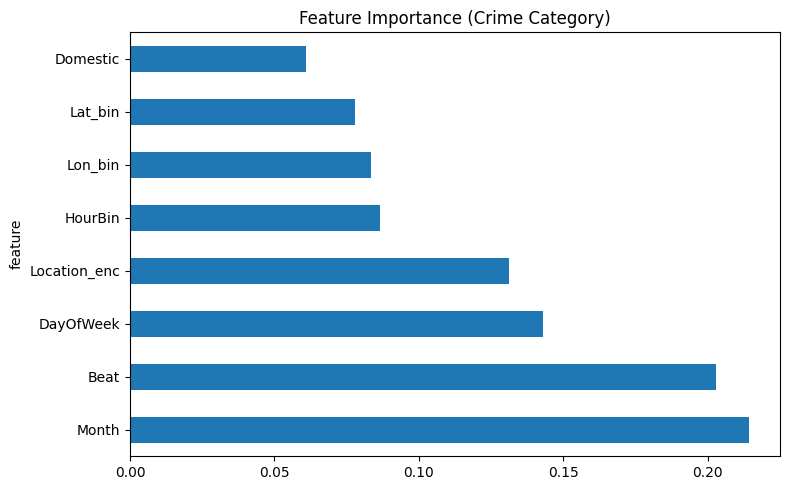

In [54]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
class_counts = y1.value_counts()
valid = class_counts[class_counts >= 2].index
m = y1.isin(valid)
X1f, y1f = X1[m], y1[m]
X_tr, X_te, y_tr, y_te = train_test_split(X1f, y1f, test_size=0.2, random_state=42, stratify=y1f)
rf.fit(StandardScaler().fit_transform(X_tr), y_tr)
imp = pd.DataFrame({'feature': feat_crime, 'importance': rf.feature_importances_}).sort_values('importance', ascending=False)
imp.plot(x='feature', y='importance', kind='barh', figsize=(8, 5), legend=False)
plt.title('Feature Importance (Crime Category)')
plt.tight_layout()
plt.show()